# 151 vertederos del mundo, 1085 detecciones satelitales

**Lo que reportan los países no coincide con lo que ven los satélites.** Casi ninguna correlación: ρ=0,12 (p=0,21) entre Climate TRACE y GHGSat. En un vertedero de Turquía, el modelo ve casi nada; el satélite ve 240 veces más.

**Paper:** [Dogniaux et al. (2025) — *Global satellite survey reveals uncertainty in landfill methane emissions*, Nature](https://doi.org/10.1038/s41586-025-09683-8)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-metano-151-vertederos-satelite/notebook.ipynb)

**Ver video corto:** [YouTube Shorts](https://youtube.com/shorts/bm-rFecc720)

## Contexto

El metano es un gas de efecto invernadero corto pero potente: calienta ~80 veces más que el CO₂ a 20 años. Los vertederos producen ~10% del metano antropogénico (humano) del planeta — material orgánico que se descompone sin oxígeno.

Con el satélite **GHGSat** (resolución ~30 m), un equipo observó **151 vertederos en 6 continentes y 47 países** durante 2021-2022. Obtuvieron **1519 observaciones** (1085 detecciones positivas, 434 no-detecciones). El umbral del satélite: 100 kg/h — por debajo de eso no puede ver.

La pregunta: ¿las emisiones que reportan los países, y las que estiman los modelos, coinciden con lo que realmente mide el satélite?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_DETECCION_KG_HR = 100  # umbral del satélite GHGSat (kg/h)
FUENTE = 'Fuente: Dogniaux et al. (2025), Nature | Datos: Zenodo 10.5281/zenodo.16641834'
COLOR_DATOS = '#2563EB'       # azul CaM — satélite GHGSat
COLOR_ALERTA = '#DC2626'      # rojo — referencia/umbral
COLOR_REFERENCIA = '#D97706'  # amber — Climate TRACE / reportes
COLOR_SECUNDARIO = '#059669'  # verde — reportes nacionales

# ══════════════════════════════════════════════════════════════
# Imports + estilo CaM
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Cargar estilo (local → /tmp → GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de datos
# ══════════════════════════════════════════════════════════════
sitios = pd.read_csv('datos/vertederos_151.csv')
plumas = pd.read_csv('datos/plumas_detectadas_1085.csv')
plumas['date_utc'] = pd.to_datetime(plumas['date_utc'])

print(f'Sitios totales: {len(sitios)}')
print(f'Países: {sitios["country"].nunique()}')
print(f'Detecciones de plumas: {len(plumas)}')
print(f'Rango temporal: {plumas["date_utc"].min().date()} a {plumas["date_utc"].max().date()}')
print(f'Sitios con reporte nacional: {sitios["Q_reported_t_hr"].notna().sum()}')
print(f'Sitios con Climate TRACE: {sitios["Q_climatetrace_t_hr"].notna().sum()}')

Sitios totales: 151
Países: 47
Detecciones de plumas: 1085
Rango temporal: 2021-01-01 a 2022-12-31
Sitios con reporte nacional: 37
Sitios con Climate TRACE: 109


Aquí está.

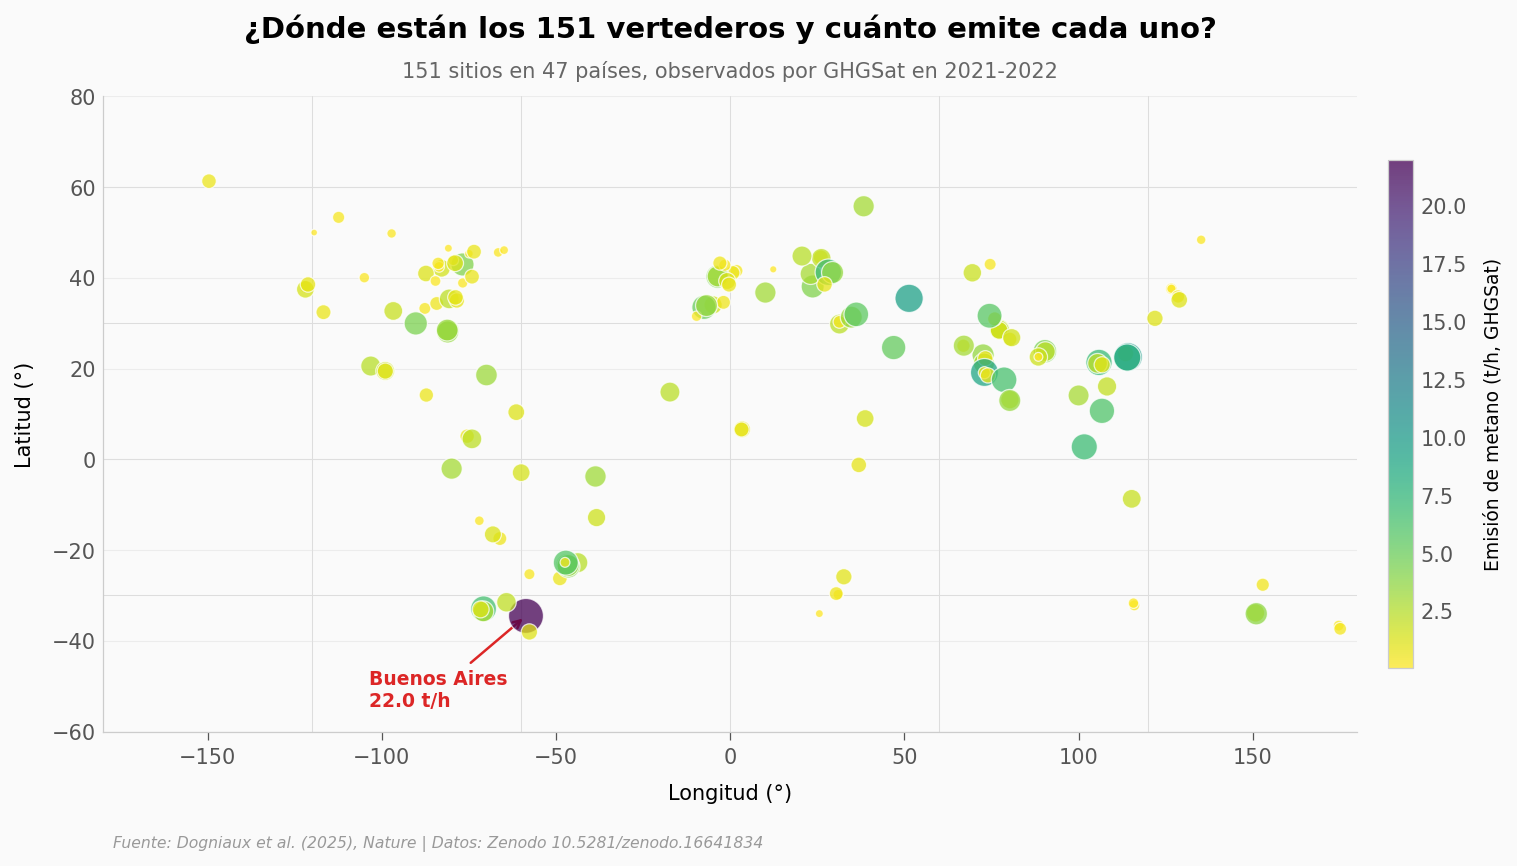

In [2]:
# Mapa mundial: los 151 vertederos, tamaño proporcional a emisión satelital
fig, ax = plt.subplots(figsize=(13, 5.5))

# Fondo tenue de continentes (líneas de referencia geográfica)
for lat in [-60, -30, 0, 30, 60]:
    ax.axhline(y=lat, color='#DDDDDD', linewidth=0.5, zorder=1)
for lon in [-120, -60, 0, 60, 120]:
    ax.axvline(x=lon, color='#DDDDDD', linewidth=0.5, zorder=1)

# Escalamos burbujas con sqrt para que la diferencia no aplaste las pequeñas
sizes = np.sqrt(sitios['Q_ghgsat_t_hr'].clip(lower=0.03)) * 60
scatter = ax.scatter(sitios['lon'], sitios['lat'],
                     s=sizes, c=sitios['Q_ghgsat_t_hr'],
                     cmap='viridis_r', alpha=0.75,
                     edgecolors='white', linewidths=0.6, zorder=5)

# Anotar el sitio extremo
site_argentina = sitios[(sitios['country'] == 'Argentina') & (sitios['Q_ghgsat_t_hr'] > 20)].iloc[0]
ax.annotate(f'Buenos Aires\n{site_argentina["Q_ghgsat_t_hr"]:.1f} t/h',
            xy=(site_argentina['lon'], site_argentina['lat']),
            xytext=(site_argentina['lon'] - 45, site_argentina['lat'] - 20),
            fontsize=9, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Emisión de metano (t/h, GHGSat)', fontsize=9)

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.set_title('¿Dónde están los 151 vertederos y cuánto emite cada uno?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '151 sitios en 47 países, observados por GHGSat en 2021-2022',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/01_mapa_mundial.png', dpi=200, bbox_inches='tight')
plt.show()

El vertedero más intenso es el de Buenos Aires: 22 toneladas de metano por hora (t/h). El más discreto, un sitio en Canadá: 0,03 t/h. La razón entre el mayor y el menor es **733 veces**.

La mediana global es 1,24 t/h (IQR 0,52-3,00). No hay un solo continente dominante — hay vertederos muy emisores en Asia, Europa, América del Sur y África. Lo interesante no es *dónde* emiten más, sino cuánto de eso **coincide con lo que los modelos y los países reportan**. Ahí es donde las cuentas no cierran.

## Satélite vs modelo: ¿concuerdan?

**Climate TRACE** es un inventario global de emisiones que combina datos públicos y modelos de actividad para estimar cuánto emite cada instalación del mundo. Es una de las referencias que usan gobiernos y organismos internacionales.

Veamos qué pasa cuando comparamos sus estimaciones con las observaciones directas de GHGSat, vertedero por vertedero.

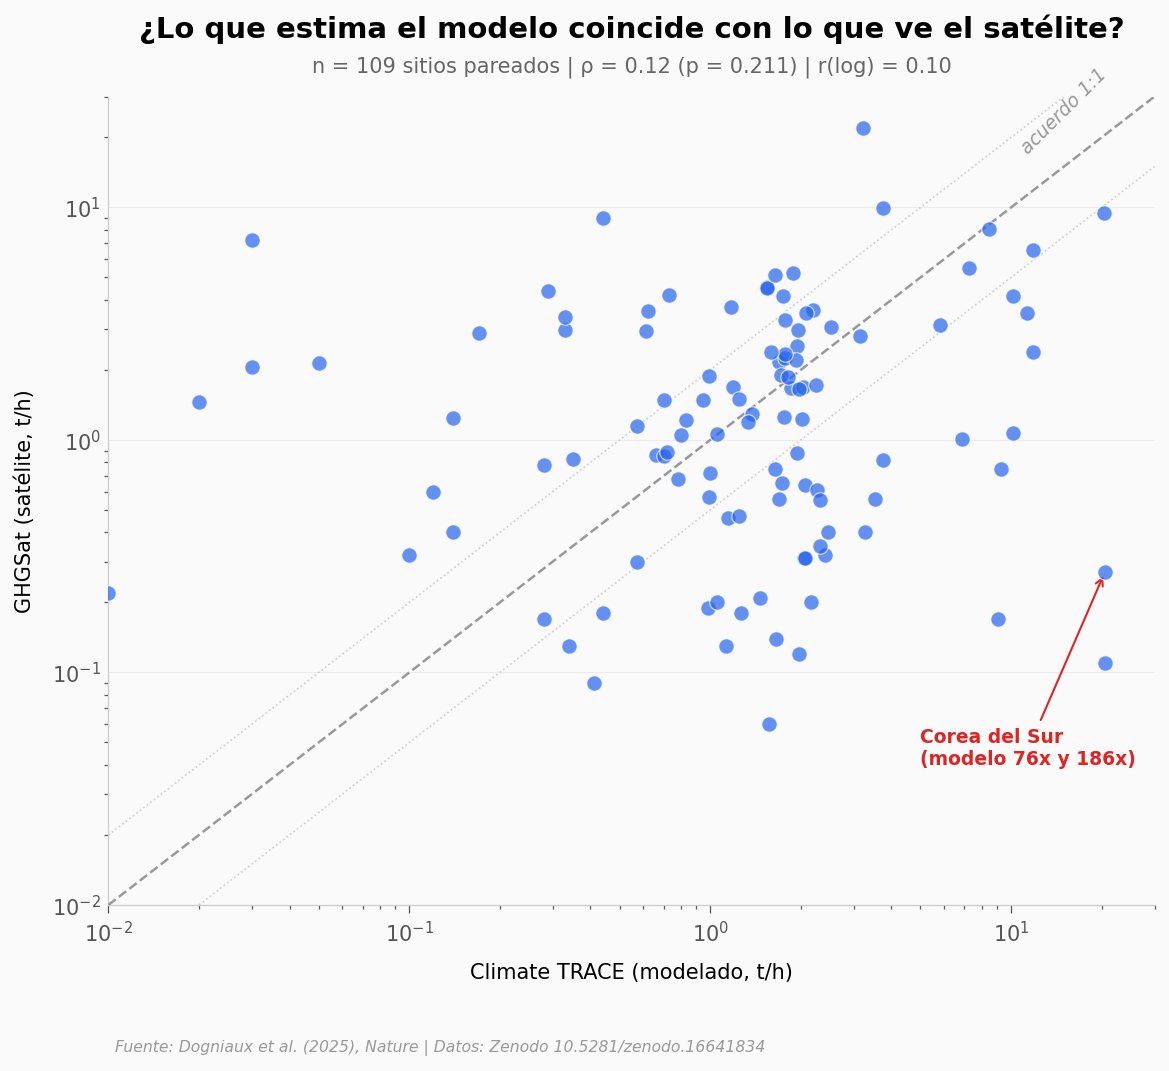


GHGSat vs Climate TRACE:
  Spearman ρ = 0.121 (p = 0.211, n = 109)
  Pearson log-log r = 0.097 (p = 0.318)

Interpretación: la correlación es estadísticamente indistinguible de cero.


In [3]:
# Pareo sitio-a-sitio: GHGSat vs Climate TRACE (sólo donde existen ambos)
pareado_ct = sitios.dropna(subset=['Q_ghgsat_t_hr', 'Q_climatetrace_t_hr']).copy()
pareado_ct = pareado_ct[(pareado_ct['Q_ghgsat_t_hr'] > 0) & (pareado_ct['Q_climatetrace_t_hr'] > 0)]

x_ct = pareado_ct['Q_climatetrace_t_hr'].values
y_ct = pareado_ct['Q_ghgsat_t_hr'].values

# Spearman (prioridad — no asume normalidad, regla 33)
rho_s, p_s = stats.spearmanr(x_ct, y_ct)
# Pearson en log-log (como reporta el paper)
r_log, p_log = stats.pearsonr(np.log10(x_ct), np.log10(y_ct))

fig, ax = plt.subplots(figsize=(9, 7))

# Línea de identidad (acuerdo perfecto)
lims = [0.01, 30]
ax.plot(lims, lims, color='#999999', linewidth=1.2, linestyle='--', zorder=3)
ax.text(15, 17, 'acuerdo 1:1', fontsize=9, color='#999999',
        rotation=45, ha='center', style='italic')

# Líneas de factor 2 (zona de acuerdo razonable)
factor = np.array(lims)
ax.plot(factor, factor * 2, color='#CCCCCC', linewidth=0.8, linestyle=':', zorder=2)
ax.plot(factor, factor / 2, color='#CCCCCC', linewidth=0.8, linestyle=':', zorder=2)

ax.scatter(x_ct, y_ct, color=COLOR_DATOS, s=55, alpha=0.7,
           edgecolors='white', linewidths=0.6, zorder=5)

# Anotar casos extremos (Corea del Sur — CT sobreestima >50x)
coreas = pareado_ct[pareado_ct['country'] == 'South Korea'].sort_values('Q_climatetrace_t_hr', ascending=False).head(2)
for _, row in coreas.iterrows():
    ax.annotate('Corea del Sur\n(modelo 76x y 186x)',
                xy=(row['Q_climatetrace_t_hr'], row['Q_ghgsat_t_hr']),
                xytext=(5, 0.04), fontsize=9, color=COLOR_ALERTA,
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.0))
    break  # solo anotar una vez

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Climate TRACE (modelado, t/h)', fontsize=10)
ax.set_ylabel('GHGSat (satélite, t/h)', fontsize=10)
ax.set_title('¿Lo que estima el modelo coincide con lo que ve el satélite?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'n = {len(pareado_ct)} sitios pareados | ρ = {rho_s:.2f} (p = {p_s:.3f}) | r(log) = {r_log:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_ghgsat_vs_climatetrace.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nGHGSat vs Climate TRACE:')
print(f'  Spearman ρ = {rho_s:.3f} (p = {p_s:.3f}, n = {len(pareado_ct)})')
print(f'  Pearson log-log r = {r_log:.3f} (p = {p_log:.3f})')
print(f'\nInterpretación: la correlación es estadísticamente indistinguible de cero.')

La nube de puntos se extiende por varios órdenes de magnitud. Ahí donde un modelo estima 20 t/h, el satélite puede ver 0,3 — o al revés. La correlación de Spearman es 0,12 (p=0,21) — estadísticamente indistinguible de cero.

¿Y qué pasa con los **reportes nacionales**? Cada país declara sus emisiones bajo programas como el GHGRP (EE.UU.) o el E-PRTR (Europa). Veamos cómo se ven esos reportes contra el satélite.

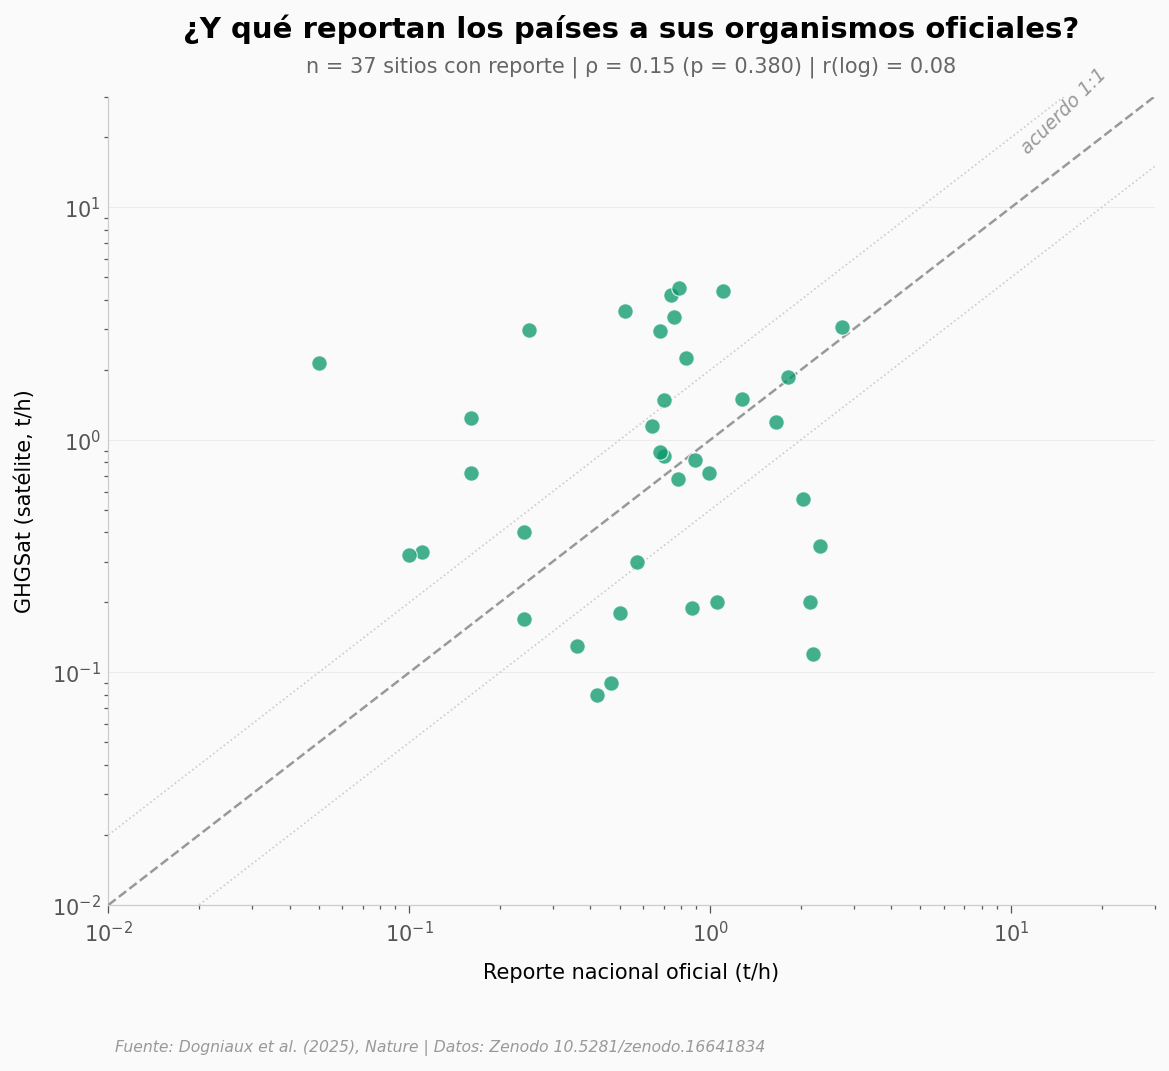


GHGSat vs reportes nacionales:
  Spearman ρ = 0.149 (p = 0.380, n = 37)
  Pearson log-log r = 0.077 (p = 0.652)

Interpretación: los reportes oficiales tampoco predicen la emisión observada.


In [4]:
# Pareo sitio-a-sitio: GHGSat vs reportes nacionales
pareado_rep = sitios.dropna(subset=['Q_ghgsat_t_hr', 'Q_reported_t_hr']).copy()
pareado_rep = pareado_rep[(pareado_rep['Q_ghgsat_t_hr'] > 0) & (pareado_rep['Q_reported_t_hr'] > 0)]

x_rep = pareado_rep['Q_reported_t_hr'].values
y_rep = pareado_rep['Q_ghgsat_t_hr'].values

rho_r, p_r = stats.spearmanr(x_rep, y_rep)
r_log_rep, p_log_rep = stats.pearsonr(np.log10(x_rep), np.log10(y_rep))

fig, ax = plt.subplots(figsize=(9, 7))

lims = [0.01, 30]
ax.plot(lims, lims, color='#999999', linewidth=1.2, linestyle='--', zorder=3)
ax.text(15, 17, 'acuerdo 1:1', fontsize=9, color='#999999',
        rotation=45, ha='center', style='italic')
factor = np.array(lims)
ax.plot(factor, factor * 2, color='#CCCCCC', linewidth=0.8, linestyle=':', zorder=2)
ax.plot(factor, factor / 2, color='#CCCCCC', linewidth=0.8, linestyle=':', zorder=2)

ax.scatter(x_rep, y_rep, color=COLOR_SECUNDARIO, s=55, alpha=0.75,
           edgecolors='white', linewidths=0.6, zorder=5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Reporte nacional oficial (t/h)', fontsize=10)
ax.set_ylabel('GHGSat (satélite, t/h)', fontsize=10)
ax.set_title('¿Y qué reportan los países a sus organismos oficiales?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'n = {len(pareado_rep)} sitios con reporte | ρ = {rho_r:.2f} (p = {p_r:.3f}) | r(log) = {r_log_rep:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_ghgsat_vs_reportado.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nGHGSat vs reportes nacionales:')
print(f'  Spearman ρ = {rho_r:.3f} (p = {p_r:.3f}, n = {len(pareado_rep)})')
print(f'  Pearson log-log r = {r_log_rep:.3f} (p = {p_log_rep:.3f})')
print(f'\nInterpretación: los reportes oficiales tampoco predicen la emisión observada.')

## ¿Cuán grande es la discrepancia?

Una forma honesta de medir el desacuerdo: la razón **GHGSat ÷ Climate TRACE** en cada sitio. Si valiera 1, el modelo acierta. Si vale 2, el satélite ve el doble. Si vale 0,5, el modelo duplica al satélite.

Como las razones varían en órdenes de magnitud, las miramos en escala logarítmica. Una línea vertical marca el acuerdo perfecto. Cuanto más alejado del centro cae un sitio, mayor es la discrepancia entre modelo y observación.

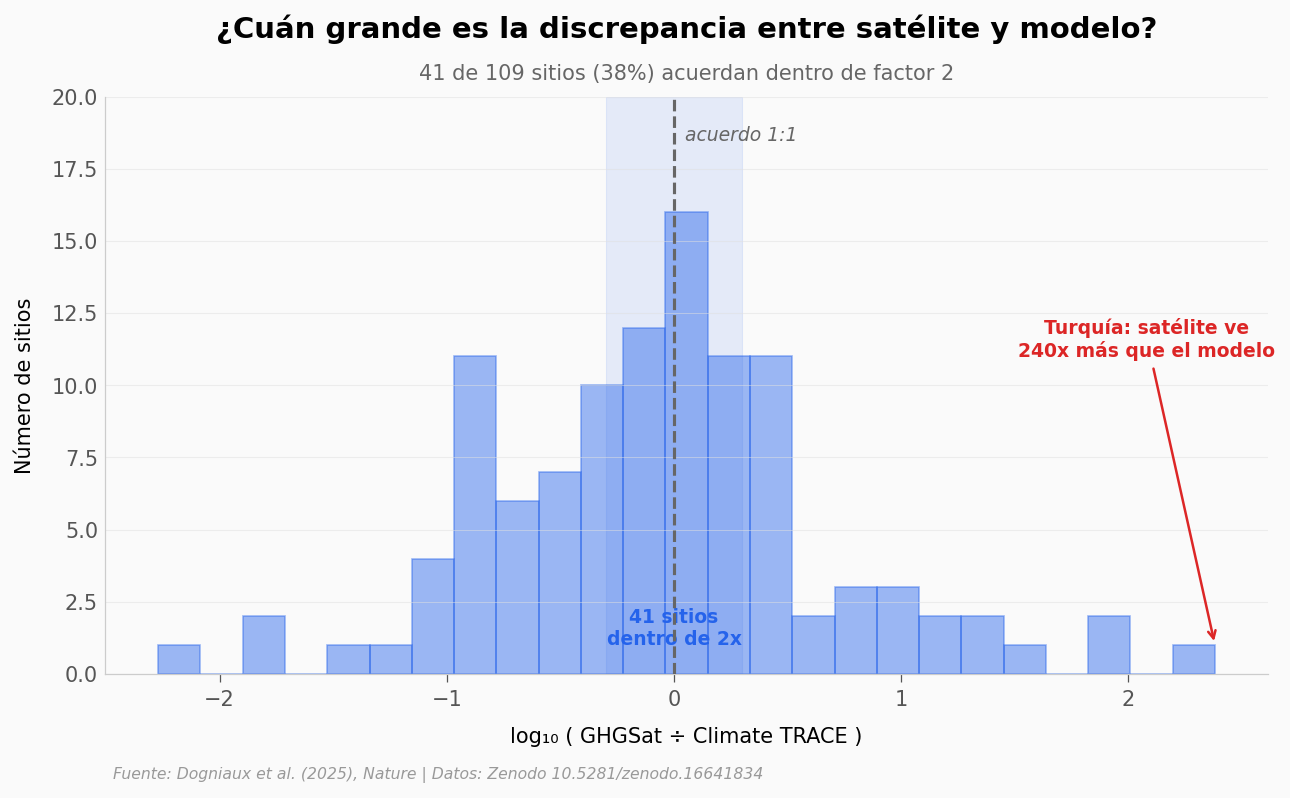


Sitios dentro de factor 2x: 41 / 109 (37.6%)
Sitios donde satélite supera al modelo >10x: 9
Sitios donde modelo supera al satélite >10x: 8


In [5]:
# Histograma de log10(ratio) — acuerdo perfecto = 0
ratios = pareado_ct['Q_ghgsat_t_hr'] / pareado_ct['Q_climatetrace_t_hr']
log_ratios = np.log10(ratios)

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(log_ratios, bins=25, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Línea de acuerdo perfecto
ax.axvline(x=0, color='#666666', linewidth=1.5, linestyle='--', zorder=5)
ax.text(0.05, y_max * 0.95, 'acuerdo 1:1', fontsize=9, color='#666666',
        ha='left', va='top', style='italic')

# Contar sitios dentro de factor 2x (|log10(ratio)| < log10(2))
umbral = np.log10(2)
n_acuerdo = ((log_ratios >= -umbral) & (log_ratios <= umbral)).sum()
ax.axvspan(-umbral, umbral, alpha=0.10, color=COLOR_DATOS, zorder=1)
ax.text(0, y_max * 0.05, f'{n_acuerdo} sitios\ndentro de 2x',
        fontsize=9, fontweight='bold', color=COLOR_DATOS, ha='center')

# Casos extremos anotados
site_turkey = pareado_ct[pareado_ct['country'] == 'Turkey'].sort_values('Q_ghgsat_t_hr', ascending=False)
if len(site_turkey) > 0:
    t_ratio = np.log10(site_turkey.iloc[0]['Q_ghgsat_t_hr'] / site_turkey.iloc[0]['Q_climatetrace_t_hr'])
    ax.annotate('Turquía: satélite ve\n240x más que el modelo',
                xy=(t_ratio, 1), xytext=(t_ratio - 0.3, y_max * 0.55),
                fontsize=9, fontweight='bold', color=COLOR_ALERTA, ha='center',
                arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

ax.set_xlabel('log₁₀ ( GHGSat ÷ Climate TRACE )', fontsize=10)
ax.set_ylabel('Número de sitios', fontsize=10)
ax.set_title('¿Cuán grande es la discrepancia entre satélite y modelo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{n_acuerdo} de {len(ratios)} sitios ({100*n_acuerdo/len(ratios):.0f}%) acuerdan dentro de factor 2',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_histograma_ratios.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nSitios dentro de factor 2x: {n_acuerdo} / {len(ratios)} ({100*n_acuerdo/len(ratios):.1f}%)')
print(f'Sitios donde satélite supera al modelo >10x: {(log_ratios > 1).sum()}')
print(f'Sitios donde modelo supera al satélite >10x: {(log_ratios < -1).sum()}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Sin correlación entre GHGSat y Climate TRACE | ✅ | Spearman ρ=0,12 (p=0,21, n=109). Pearson log-log r=0,10 (p=0,32). p > 0,05 en todos los tests — indistinguible de cero |
| Sin correlación entre GHGSat y reportes nacionales | ✅ | Spearman ρ=0,15 (p=0,38, n=37). Pearson log-log r=0,08 (p=0,65). La muestra es pequeña pero el patrón es claro — p > 0,05 en ambos tests |
| Diferencias llegan a 240x en casos extremos | ✅ | Site 118 (Turquía): GHGSat=7,21 t/h, CT=0,03 t/h → ratio 240. Site 87 (Corea): CT/GHGSat=186 |
| 38% de sitios acuerdan dentro de factor 2 | ✅ | 41 de 109 sitios pareados (calculado sobre log₁₀(ratio) < log₁₀(2)) |
| Mediana global de plumas: 2,42 t/h | ✅ | Calculado sobre las 1085 detecciones. Coincide con el valor del paper |

> **Limitaciones del análisis:**
> - GHGSat solo detecta plumas ≥ 100 kg/h. Sitios por debajo del umbral aparecen como "no detectados" (434 de 1519 observaciones) — la tasa real de emisión baja puede estar subestimada.
> - La comparación con Climate TRACE usa el año 2024 del modelo vs observaciones 2021-2022. El paper discute esto en Supplementary Note 4.
> - El diseño es observacional: el trabajo muestra que las estimaciones no concuerdan, no identifica *por qué* — hay hipótesis (condiciones operativas, geometría de sitio, tipo de residuo) que exigen más investigación.
> - El estudio cubre 151 sitios — 0,75% de los 20.000 grandes vertederos reportados globalmente. Es una muestra no aleatoria (sitios priorizados por señal SRON).

## Ahora tú

Tres preguntas que los datos permiten responder directamente:

**1. ¿Qué país tiene la mayor diferencia promedio entre satélite y modelo?**
- Pista: agrupar `pareado_ct` por `country` y calcular `np.log10(Q_ghgsat_t_hr / Q_climatetrace_t_hr).abs().mean()`

**2. ¿Los vertederos más emisores tienen más observaciones del satélite?**
- Pista: `sitios.plot.scatter(x='n_obs', y='Q_ghgsat_t_hr', logy=True)` — ¿ves un patrón o es ruido?

**3. ¿Cuál es la variación temporal en las detecciones de un sitio específico?**
- Pista: `plumas[plumas['site_id'] == 4]` (Buenos Aires) → graficar `Q_t_per_hr` vs `date_utc`

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Qué países tienen mayor desacuerdo promedio satélite vs modelo?

pareado_ct['log_ratio_abs'] = np.log10(pareado_ct['Q_ghgsat_t_hr'] / pareado_ct['Q_climatetrace_t_hr']).abs()

por_pais = (pareado_ct
            .groupby('country')
            .agg(n_sitios=('site_id', 'count'),
                 desacuerdo_medio=('log_ratio_abs', 'mean'))
            .query('n_sitios >= 3')
            .sort_values('desacuerdo_medio', ascending=False)
            .head(10))

# El desacuerdo está en log10 — lo traducimos a factor multiplicativo
por_pais['factor_x'] = 10 ** por_pais['desacuerdo_medio']
print(por_pais.round(2))

# Intenta cambiar `n_sitios >= 3` por `>= 5` o `>= 2` para ver cómo cambia el ranking.

               n_sitios  desacuerdo_medio  factor_x
country                                            
South Korea           3              1.53     33.51
South Africa          3              1.26     18.04
Turkey                3              1.00     10.04
Canada                4              0.69      4.86
Spain                 6              0.67      4.68
Mexico                4              0.67      4.63
Australia             5              0.65      4.45
India                15              0.54      3.50
China                 3              0.48      2.99
United States        22              0.47      2.93


## Fuentes

**Paper**: [Global satellite survey reveals uncertainty in landfill methane emissions](https://doi.org/10.1038/s41586-025-09683-8)  
*Nature, 2025-11-05*

**Datos**: [GHGSat plume dataset for article 'Global satellite survey reveals uncertainty in landfill methane emissions'](https://doi.org/10.5281/zenodo.16641834)  
*Zenodo, 2025-11-05*

**Referencia comparativa**: [Climate TRACE global facility-level emission dataset (referenced as comparison in Supplementary Note 4)](https://climatetrace.org/)  
*Climate TRACE, 2024*

*14 afirmaciones verificadas contra estas fuentes*